In [18]:
import numpy as np

# 유전자 정보 4개를 가진 학습 데이터
X = np.array([[2.54, 4.33, 3.99, 2.57],  # 환자 A
    [3.12, 3.87, 3.84, 3.04],  # 환자 B
    [2.76, 4.17, 5.63, 3.28],  # 환자 C
    [3.87, 3.56, 4.25, 3.65],  # 환자 D
    [3.55, 3.91, 2.68, 4.22],  # 환자 E
    [4.12, 2.86, 3.30, 3.71]]) # 환자 F

# 확진 여부
labels = np.array(["정상", "정상", "정상", "확진", "확진", "확진"])

# 신입 환자 데이터
new = np.array([[3.24, 3.68, 3.82, 3.77]])

In [19]:
distances = np.sqrt(np.sum((X - new) ** 2, axis=1))
print(distances)

[1.54317854 0.76406806 1.99667223 0.78140898 1.28495136 1.31179267]


In [20]:
idx = np.argmin(distances)

print("\n가장 가까운 환자:", idx)
print("예측 결과:", labels[idx])


가장 가까운 환자: 1
예측 결과: 정상


In [21]:
from sklearn.neighbors import KNeighborsClassifier  

knr = KNeighborsClassifier(n_neighbors=1) #객체 생성

knr.fit(X, labels)#훈련

KNeighborsClassifier(n_neighbors=1)

In [22]:
knr.predict(new)

array(['정상'], dtype='<U2')

In [23]:
k = 3

# 가장 가까운 k개 인덱스
idx = np.argsort(distances)[:k]

votes = labels[idx]

print(votes)
if (np.sum(votes == "확진") > np.sum(votes == "정상")): print("확진")
else: print("정상")

['정상' '확진' '확진']
확진


In [24]:
knr = KNeighborsClassifier(n_neighbors=3) #객체 생성

knr.fit(X, labels)#훈련
knr.predict(new)

array(['확진'], dtype='<U2')

In [25]:
# 입력 데이터 (다른 과목 점수)
X = np.array([ [7.5, 7.5, 7.0, 9.5, 8.5],# 학생0
    [7.5, 7.0, 7.5, 8.0, 8.0],  # 학생1
    [8.0, 7.0, 8.0, 8.0, 8.5],  # 학생2
    [8.5, 8.0, 9.5, 7.5, 6.0],  # 학생3
    [10.0, 9.5, 9.0, 7.5, 7.5], # 학생4
    [9.0, 9.0, 8.0, 8.0, 8.0]])  # 학생5

# 정답 (인공지능 점수)
y = np.array([5.0, 6.0, 8.5, 7.0, 10.0, 9.0])

# 신입 학생
new = np.array([9.0, 8.5, 8.0, 7.0, 8.0])

In [26]:
distances = np.sqrt(np.sum((X - new) ** 2, axis=1))

idx = np.argsort(distances)# 가까운 순서대로 인덱스 정렬

k=3# k=3 선택
nearY = y[idx[:k]]
print(nearY)

pred = np.mean(nearY)# 평균 (회귀 결과)

print("예측값:", pred)

[ 9.  10.   8.5]
예측값: 9.166666666666666


In [27]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(X, y)# 학습

# 예측
pred = knr.predict([new])
print("예측값:", pred[0])

예측값: 9.166666666666666


In [28]:
import pandas as pd
train = pd.read_csv('./data/basketball_train.csv')
test = pd.read_csv('./data/basketball_test.csv')

print(train.head(3))
print(test.head(3))

   Unnamed: 0           Player Pos   3P  TRB  BLK
0          26  Wayne Ellington  SG  2.4  2.1  0.1
1          86     Nik Stauskas  SG  1.7  2.8  0.4
2          60         Alex Len   C  0.0  6.6  1.3
   Unnamed: 0           Player Pos   3P  TRB  BLK
0          96      Dwyane Wade  SG  0.8  4.5  0.7
1          39     Tim Hardaway  SG  1.9  2.8  0.2
2          21  Jordan Crawford  SG  1.9  1.8  0.1


In [29]:
#train
X_train = train[['3P', 'BLK']].values
y_train = train['Pos'].values

#test
X_test = test[['3P', 'BLK']].values
y_test = test['Pos'].values

X_train.shape, X_test.shape

((80, 2), (20, 2))

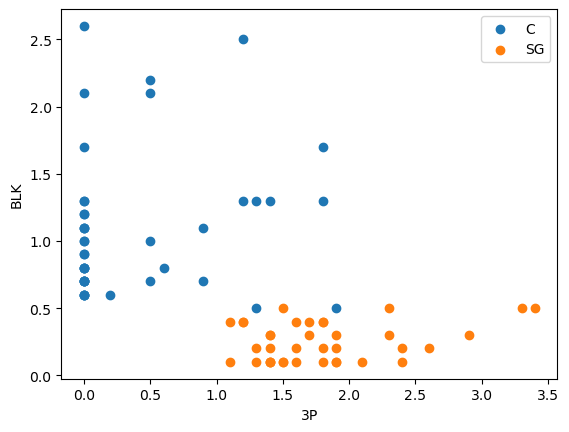

In [30]:
import matplotlib.pyplot as plt

label = np.unique(y_train)

for p in label:
    idx = np.where(y_train == p)[0]
    plt.scatter(X_train[idx,0], X_train[idx,1], label = p)

plt.xlabel("3P") # x축 표시
plt.ylabel("BLK") # y축 표시
plt.legend()
plt.show()

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy = []
k = np.arange(1,11)#k=1~10

for i in k:
    kNN = KNeighborsClassifier(n_neighbors = i)
    kNN.fit(X_train, y_train)
    y_pred = kNN.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))
  
print(accuracy)
print(np.argmax(accuracy)+1)

[0.8, 0.75, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9]
3


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 13, 14, 15, 16, 17, 18,
       19], dtype=int64),)


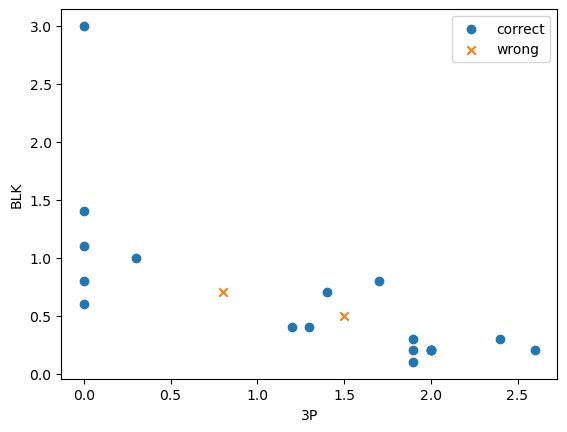

In [32]:
#최적의 k값으로 학습
kNN = KNeighborsClassifier(n_neighbors = 3)
kNN.fit(X_train, y_train)

#예측값
y_pred = kNN.predict(X_test)

#그래프
crr_idx = np.where(y_test== y_pred)
wr_idx = np.where(y_test!= y_pred)

plt.scatter(X_test[crr_idx,0], X_test[crr_idx,1],  marker='o', label='correct')
plt.scatter(X_test[wr_idx,0], X_test[wr_idx,1],  marker='x', label='wrong')

plt.xlabel("3P")
plt.ylabel("BLK")
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 6  1]
 [ 1 12]]
              precision    recall  f1-score   support

           C       0.86      0.86      0.86         7
          SG       0.92      0.92      0.92        13

    accuracy                           0.90        20
   macro avg       0.89      0.89      0.89        20
weighted avg       0.90      0.90      0.90        20

